In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data=pd.read_csv('/content/Mall_Customers.csv')
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
data.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
data.isna().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


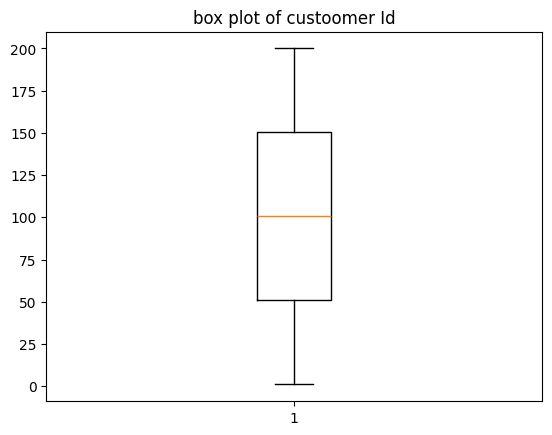

In [ ]:
plt.boxplot(data['CustomerID'])
plt.title('box plot of custoomer Id')
plt.show()

In [ ]:
y=data['CustomerID']

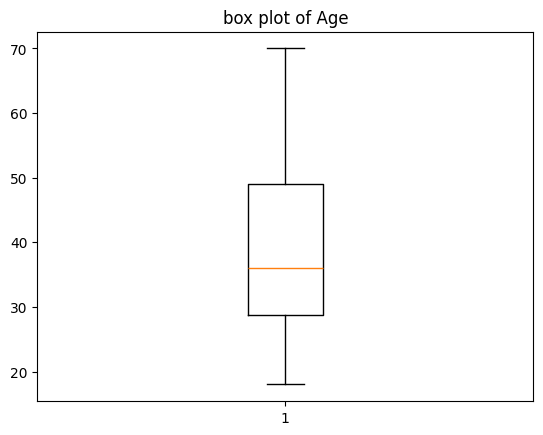

In [ ]:
plt.boxplot(data['Age'])
plt.title('box plot of Age')
plt.show()

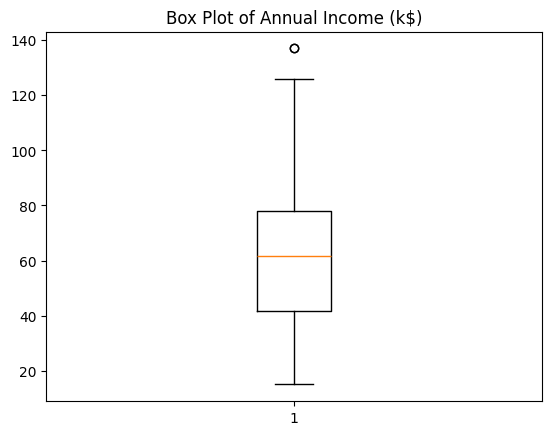

In [ ]:
plt.boxplot(data['Annual Income (k$)'])
plt.title('Box Plot of Annual Income (k$)')
plt.show()

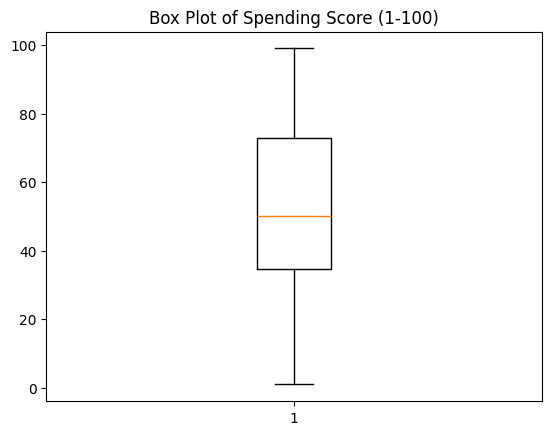

In [ ]:
plt.boxplot(data['Spending Score (1-100)'])
plt.title('Box Plot of Spending Score (1-100)')
plt.show()

In [ ]:
Q1 = np.percentile(data['Annual Income (k$)'], 25)
Q2 = np.percentile(data['Annual Income (k$)'], 50)
Q3 = np.percentile(data['Annual Income (k$)'], 75)

In [ ]:
print(Q1)
print(Q2)
print(Q3)

41.5
61.5
78.0


In [ ]:
data['Annual Income (k$)'].median()

61.5

In [ ]:
IQR = Q3 - Q1
print(IQR)

36.5


In [ ]:
up_lim = Q3 + 1.5 * IQR
low_lim = Q1 - 1.5 * IQR

In [ ]:
print(up_lim)
print(low_lim)

132.75
-13.25


In [ ]:
outlier = []

for x in data['Annual Income (k$)']:
  if x > up_lim or x < low_lim:
    outlier.append(x)


outlier

[137, 137]

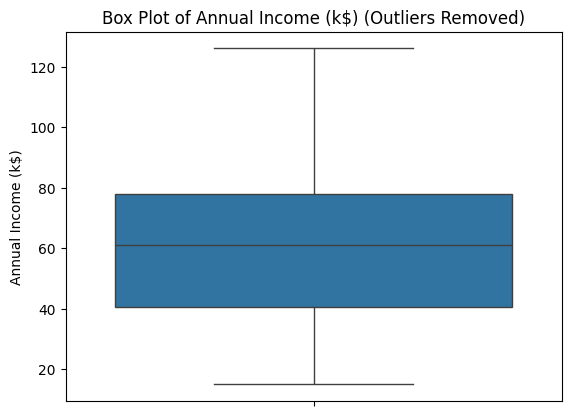

In [ ]:
sns.boxplot(data=data_no_outliers['Annual Income (k$)'])
plt.title('Box Plot of Annual Income (k$) (Outliers Removed)')
plt.show()

In [ ]:
data_no_outliers = data[~data['Annual Income (k$)'].isin(outlier)]
display(data_no_outliers.head())

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
data['Genre'] = data['Genre'].map({'Male':1,'Female':0})
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


**K means ++**
planned and unplanned

Elbow Method

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
x = data.drop('CustomerID', axis=1)
wcss=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42,n_init=10)
  kmeans.fit(x)
  wcss.append(kmeans.inertia_)

In [ ]:
print(wcss)

[308862.06000000006, 212889.44245524294, 143391.59236035674, 104414.67534220174, 75399.61541401486, 58348.64136331505, 51130.690081263754, 44687.23553400544, 40857.18667502088, 37175.97669994117]


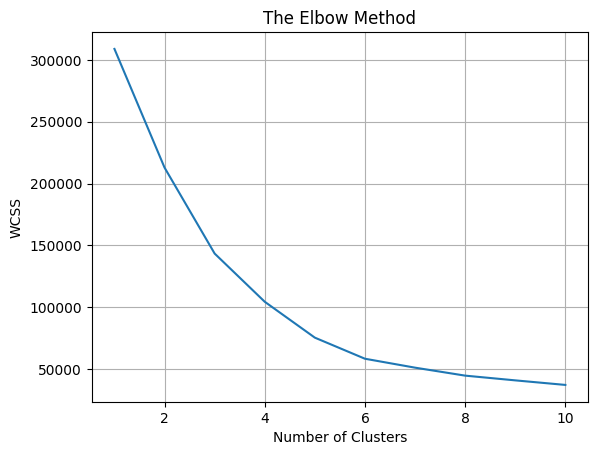

In [ ]:
plt.plot(range(1,11),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid()
plt.show()

In [ ]:
km=KMeans(n_clusters=5,init='k-means++',random_state=42,n_init=10)
km.fit(x)
cluster_labels=km.predict(x)

In [ ]:
print(cluster_labels)

[0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0
 4 0 4 0 4 0 4 0 4 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 2 3 2 1 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 1 2 3 2 3 2
 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3
 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2]


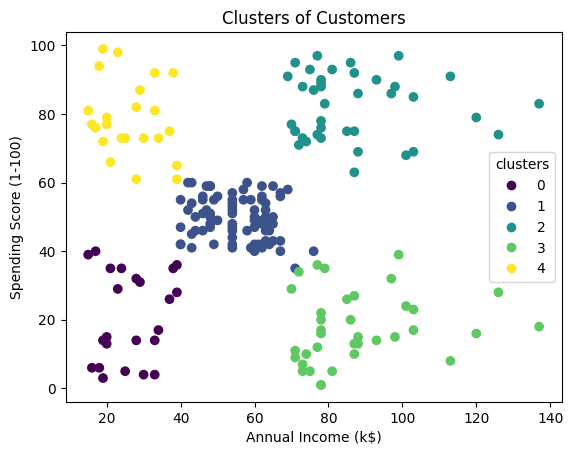

In [ ]:
scatter=plt.scatter(x['Annual Income (k$)'],x['Spending Score (1-100)'],c=cluster_labels)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Clusters of Customers')
plt.legend(*scatter.legend_elements(),title="clusters")
plt.show()

In [ ]:
#function to predict cluster for new customer
def predict_cluster(genre, age, annual_income, spending_score):
    new_customer = pd.DataFrame({'Genre': [genre], 'Age': [age], 'Annual Income (k$)': [annual_income], 'Spending Score (1-100)': [spending_score]})
    cluster_label = km.predict(new_customer)
    return cluster_label[0]

In [ ]:
#example
new_customer_income=50
new_customer_age=25
new_customer_spending=100
genre='Male'
genre=1 if genre=='Male' else 0


In [ ]:
predicted_cluster=predict_cluster(
    genre=genre,
    age=new_customer_age,
    annual_income=new_customer_income,
    spending_score=new_customer_spending
)
print(f'the customer belongs to {predicted_cluster}')

the customer belongs to 4
